# Decision-threshold optimization

This notebook optimizes the random forest decision threshold based on
estimated maintenance costs.

A missed machine failure is assumed to be substantially more expensive than
an unnecessary maintenance inspection.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from predictive_maintenance.data import load_data
from predictive_maintenance.evaluate import (
    calculate_metrics,
    find_cost_optimal_threshold,
)
from predictive_maintenance.features import create_features
from predictive_maintenance.train import (
    create_random_forest_model,
    split_data,
)

In [3]:
df = load_data()
X, y = create_features(df)

X_train_full, X_test, y_train_full, y_test = split_data(X, y)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full,
)

print(f"Training observations: {len(X_train)}")
print(f"Validation observations: {len(X_validation)}")
print(f"Test observations: {len(X_test)}")

Loading local dataset from /Users/alexanderkorolev/Desktop/predictive-maintenance-ai4i/data/raw/ai4i2020.csv
Training observations: 6000
Validation observations: 2000
Test observations: 2000


In [4]:
random_forest_model = create_random_forest_model(X_train)

random_forest_model.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Type','Air temperature','Process temperature','Rotational speed', 'Torque','Tool wear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [5]:
validation_probabilities = random_forest_model.predict_proba(
    X_validation
)[:, 1]

best_threshold, threshold_results = find_cost_optimal_threshold(
    target=y_validation,
    probabilities=validation_probabilities,
    false_positive_cost=100.0,
    false_negative_cost=5000.0,
)

print(f"Cost-optimal threshold: {best_threshold:.2f}")

Cost-optimal threshold: 0.08


In [6]:
best_result = threshold_results.loc[
    threshold_results["threshold"] == best_threshold
]

best_result

,threshold,true_negative,false_positive,false_negative,true_positive,total_cost
7,0.08,1724,208,4,64,40800.0


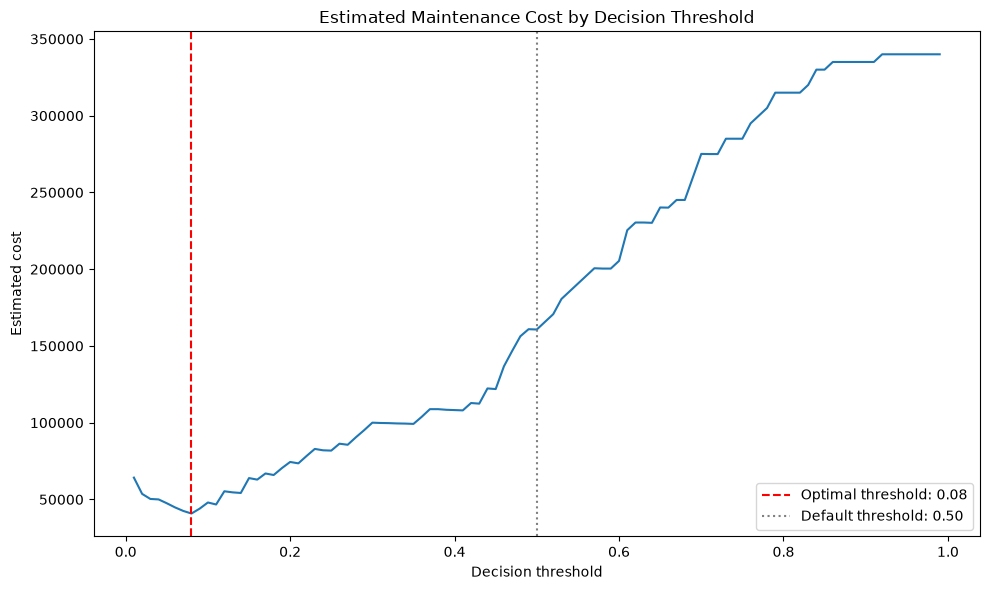

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["total_cost"],
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Optimal threshold: {best_threshold:.2f}",
)

plt.title("Estimated Maintenance Cost by Decision Threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Estimated cost")
plt.axvline(
    0.5,
    color="gray",
    linestyle=":",
    label="Default threshold: 0.50",
)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation

The cost-based optimization selects a decision threshold of 0.08. This is
substantially lower than the default threshold of 0.50 because a missed
machine failure is assumed to cost 50 times more than a false maintenance
alarm.

The lower threshold causes the model to issue warnings at smaller predicted
failure probabilities. This is expected to increase recall and reduce the
number of undetected failures, while producing more false alarms.

The selected threshold is not universally optimal. It depends on the assumed
costs and would need to be validated using actual maintenance and downtime
costs in a real industrial application.

In [8]:
default_metrics = calculate_metrics(
    random_forest_model,
    X_test,
    y_test,
    threshold=0.5,
)

optimized_metrics = calculate_metrics(
    random_forest_model,
    X_test,
    y_test,
    threshold=best_threshold,
)

comparison = pd.DataFrame(
    [
        {
            "setting": "Default threshold (0.50)",
            **default_metrics,
        },
        {
            "setting": f"Optimized threshold ({best_threshold:.2f})",
            **optimized_metrics,
        },
    ]
)

comparison.set_index("setting").round(3)

,accuracy,precision,recall,f1_score,pr_auc
setting,,,,,
Default threshold (0.50),0.977,0.712,0.544,0.617,0.726
Optimized threshold (0.08),0.908,0.259,0.912,0.404,0.726


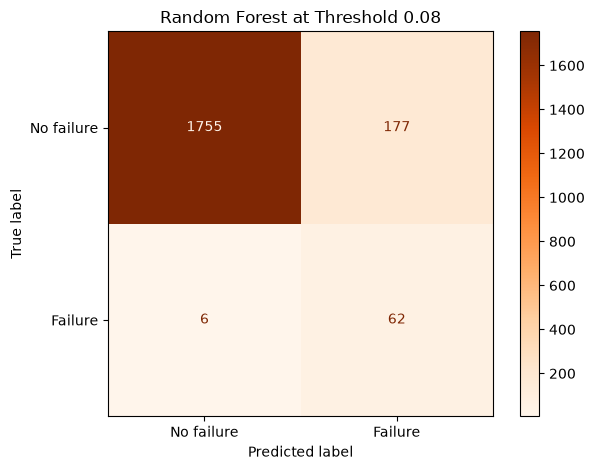

In [9]:
test_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

optimized_predictions = (
    test_probabilities >= best_threshold
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_predictions,
    display_labels=["No failure", "Failure"],
    cmap="Oranges",
)

plt.title(
    f"Random Forest at Threshold {best_threshold:.2f}"
)
plt.tight_layout()
plt.show()

## Test-set interpretation

At the optimized threshold of 0.08, the random forest detects 62 of 68
machine failures. This corresponds to a recall of approximately 91.2%.
Only 6 failures remain undetected.

The lower threshold increases the number of false alarms to 177 and reduces
precision to approximately 25.9%. Based on the assumed costs of EUR 100 per
false alarm and EUR 5,000 per missed failure, the estimated total cost is
EUR 47,700.

The optimized threshold therefore prioritizes failure detection over alarm
precision. Whether this trade-off is appropriate depends on the actual costs
of inspections, downtime, machine damage, and production losses.